# Comparative Analysis — Greedy vs Genetic

This notebook compares the greedy and genetic results using the measured values stored in `comparative_results.json`.

It includes:
- a direct metric comparison
- visualizations for the main performance indicators
- an interpretation of the tradeoff between solution quality and runtime

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

plt.style.use("ggplot")

results_path = Path("comparative_results.json")
data = json.loads(results_path.read_text(encoding="utf-8"))

greedy = data["greedy"]
genetic = data["genetic_best"]
improvement = data["improvement_vs_greedy"]

greedy, genetic, improvement

({'fitness': 30011.483217219014,
  'energy_kwh': 11.483217219013351,
  'violations': 3,
  'unserved': 0,
  'served': 20,
  'routes': 13,
  'runtime_sec': 0.0031789999920874834},
 {'fitness': 30010.631158035718,
  'energy_kwh': 10.631158035716485,
  'violations': 3,
  'unserved': 0,
  'served': 20,
  'routes': 13,
  'runtime_sec': 6.257433000020683},
 {'fitness_pct': 0.0028391105402207958,
  'energy_pct': 7.420038888457742,
  'runtime_pct': -196736.52140910365})

## Notebook guide

The notebook reads the stored comparison summary and focuses on the metrics that matter most:

- fitness
- energy usage
- constraint violations
- unserved customers
- routes used
- runtime

The most important interpretation is whether the genetic algorithm improves solution quality enough to justify its much larger runtime cost.

In [2]:
metrics = ["fitness", "energy_kwh", "violations", "unserved", "routes", "runtime_sec"]

print("COMPARATIVE ANALYSIS - GREEDY VS GENETIC")
print("=" * 70)
print(f"{'Metric':<16}{'Greedy':>15}{'Genetic':>15}{'Delta':>15}")
print("-" * 70)

for metric in metrics:
    g = greedy[metric]
    ga = genetic[metric]
    delta = g - ga
    print(f"{metric:<16}{g:>15.6f}{ga:>15.6f}{delta:>15.6f}")

print("=" * 70)

COMPARATIVE ANALYSIS - GREEDY VS GENETIC
Metric                   Greedy        Genetic          Delta
----------------------------------------------------------------------
fitness            30011.483217   30010.631158       0.852059
energy_kwh            11.483217      10.631158       0.852059
violations             3.000000       3.000000       0.000000
unserved               0.000000       0.000000       0.000000
routes                13.000000      13.000000       0.000000
runtime_sec            0.003179       6.257433      -6.254254


## Raw comparison table interpretation

This comparison shows that both methods solve the same problem structure:

- both serve all 20 customers
- both use 13 routes
- both keep the same number of constraint violations

The key difference is that the genetic method achieves lower energy and slightly better fitness, but at a much higher runtime.

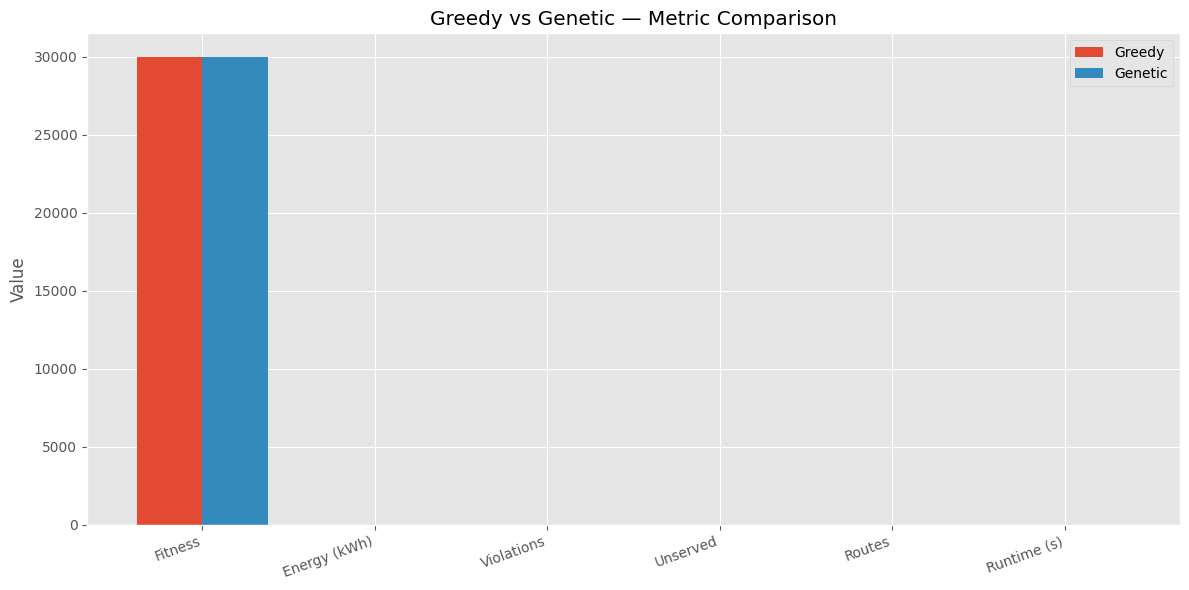

In [3]:
labels = ["Fitness", "Energy (kWh)", "Violations", "Unserved", "Routes", "Runtime (s)"]
greedy_values = [greedy["fitness"], greedy["energy_kwh"], greedy["violations"], greedy["unserved"], greedy["routes"], greedy["runtime_sec"]]
genetic_values = [genetic["fitness"], genetic["energy_kwh"], genetic["violations"], genetic["unserved"], genetic["routes"], genetic["runtime_sec"]]

x = range(len(labels))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar([i - width / 2 for i in x], greedy_values, width=width, label="Greedy")
ax.bar([i + width / 2 for i in x], genetic_values, width=width, label="Genetic")
ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_title("Greedy vs Genetic — Metric Comparison")
ax.set_ylabel("Value")
ax.legend()
plt.tight_layout()
plt.show()

## Metric chart interpretation

The chart makes two things obvious:

1. The genetic algorithm reduces energy.
2. The genetic algorithm is dramatically slower.

The remaining metrics are unchanged, which means the quality improvement is focused on route efficiency rather than feasibility or coverage.

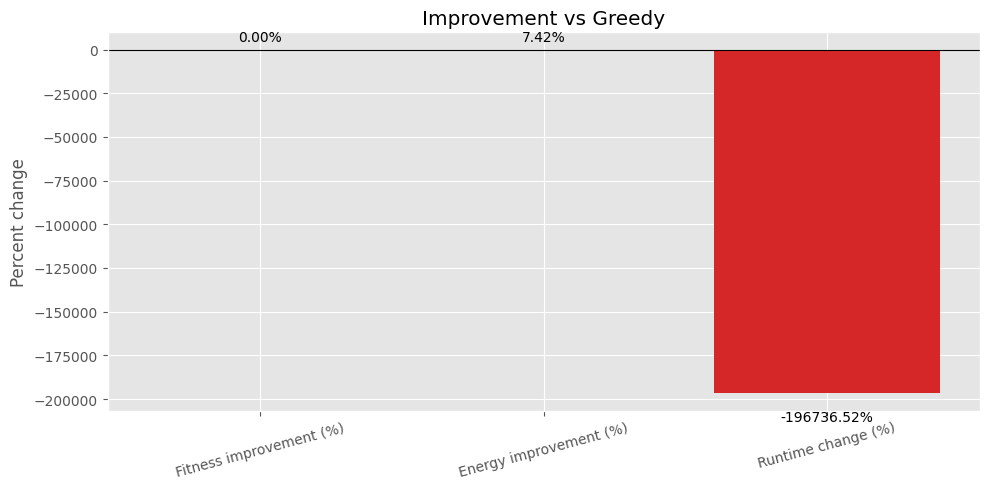

In [4]:
improvement_metrics = ["fitness_pct", "energy_pct", "runtime_pct"]
improvement_labels = ["Fitness improvement (%)", "Energy improvement (%)", "Runtime change (%)"]
improvement_values = [improvement["fitness_pct"], improvement["energy_pct"], improvement["runtime_pct"]]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(improvement_labels, improvement_values, color=["#2ca02c", "#1f77b4", "#d62728"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Improvement vs Greedy")
ax.set_ylabel("Percent change")
ax.tick_params(axis="x", rotation=15)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f"{height:.2f}%",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4 if height >= 0 else -12),
                textcoords="offset points",
                ha="center",
                va="bottom" if height >= 0 else "top")

plt.tight_layout()
plt.show()

## Improvement chart interpretation

The improvement chart highlights the practical tradeoff:

- fitness improves only slightly
- energy improves by a more meaningful amount
- runtime increases heavily

This means the genetic method is better if solution quality matters more than time, but greedy remains the stronger choice for fast execution.

In [5]:
energy_saved = greedy["energy_kwh"] - genetic["energy_kwh"]
runtime_multiplier = genetic["runtime_sec"] / greedy["runtime_sec"] if greedy["runtime_sec"] else float("inf")
fitness_delta = greedy["fitness"] - genetic["fitness"]

print("SUMMARY INSIGHTS")
print("=" * 70)
print(f"Energy saved by genetic: {energy_saved:.6f} kWh")
print(f"Fitness gain by genetic: {fitness_delta:.6f}")
print(f"Runtime multiplier:      {runtime_multiplier:.2f}x slower than greedy")
print(f"Greedy unserved:         {greedy['unserved']}")
print(f"Genetic unserved:        {genetic['unserved']}")
print(f"Greedy violations:       {greedy['violations']}")
print(f"Genetic violations:      {genetic['violations']}")
print("=" * 70)

SUMMARY INSIGHTS
Energy saved by genetic: 0.852059 kWh
Fitness gain by genetic: 0.852059
Runtime multiplier:      1968.37x slower than greedy
Greedy unserved:         0
Genetic unserved:        0
Greedy violations:       3
Genetic violations:      3


## Final comparative analysis

The two methods are very close in feasibility:

- both serve all customers
- both use the same number of routes
- both have the same number of violations

The genetic algorithm produces a better energy result and slightly better fitness, but its runtime is much larger. That makes the greedy heuristic the better baseline for speed, while the genetic algorithm is the better choice when quality improvement is worth the extra compute time.

This notebook therefore provides both a numerical comparison and a visual explanation of the tradeoff.